# Изучение рынка заведений общественного питания Москвы

## Цели и задачи проекта

**Цель:** провести исследовательский анализ рынка заведений общественного питания Москвы

**Задачи:**
1. Загрузка и знакомство с данными
2. Проведение предобработки данных
3. Проведение исследовательского анализа данных
4. Формирование выводов исследования и рекомендаций

## Описание данных

Для анализа предоставлены два датасета, содержащие информацию о заведениях общественного питания в г. Москве на лето 2022 года:

- 'rest_info.csv' - содержит информацию о заведениях общественного питания;
- 'rest_price.csv' - содержит информацию о среднем чеке в заведениях общественного питания.

### Описание данных датасета 'rest_info.csv':

name — название заведения;

address — адрес заведения;

district — административный район, в котором находится заведение;

category — категория заведения;

hours — информация о днях и часах работы;

rating — рейтинг заведения по оценкам пользователей;

chain — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым;

seats — количество посадочных мест.

### Описание данных датасета 'rest_price.csv':

price — категория цен в заведении;

avg_bill — строка, которая хранит среднюю стоимость заказа в виде диапазона;

middle_avg_bill — число с оценкой среднего чека, которое указано только для значений из столбца avg_bill;

middle_coffee_cup — число с оценкой одной чашки капучино, которое указано только для значений из столбца avg_bill.

## Содержимое проекта

 1. Загрузка данных и знакомство с ними
 2. Предобработка данных
 3. Исследовательский анализ данных
 4. Итоговый вывод и рекомендации

## Загрузка данных и знакомство с ними

In [1]:
# Устанавливаем phik.
!pip install phik

     |████████████████████████████████| 677 kB 2.0 MB/s eta 0:00:01


In [2]:
# Импорт всех библиотек
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import phik
from phik import phik_matrix

In [3]:
# Выгружаем данные в переменные info_df и price_df
info_df = pd.read_csv('https://.../rest_info.csv')
price_df = pd.read_csv('https://.../rest_price.csv')

In [4]:
# Выгружаем первые 5 строк из info_df
info_df.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [5]:
# Выводим информацию о датафрейме
info_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


In [6]:
# Выводим первые 5 строк из price_df
price_df.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [7]:
# Выводим информацию о датафрейме
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


---

### Промежуточный вывод

Датасет **"rest_info.csv"** включает в себя 8406 строк и 9 столбцов и содержит общую информацию о заведениях общественного питания.
Первичный осмотр данных позволяет сделать следующие выводы:
- названия столбцов приведены в соответствие с правилами snake case;
- тип данных столбцов соответствует ожидаемым;
- пропуски содержатся в столбцах hours и seats;
- столбец hours содержит неоднародную информацию о времени работы заведений. Возможно потребуется более детальная категоризация этих данных.
- в описании данных датасета пропущен столбец id, который идентифицирует заведения

Датасет **"rest_price.csv"** включает в себя 4058 строк и 5 столбцов и содержит информацию о средних ценах в заведениях общественного питания.
Первичный осмотр данных позволяет сделать следующие выводы:
- названия столбцов приведены в соответствие с правилами snake case;
- тип данных столбцов соответствует ожидаемым;
- пропуски содержатся в столбцах price, avg_bill, middle_avg_bill, middle_coffee_cup;
- в описании данных датасета пропущен столбец id, который идентифицирует заведения;
- количество строк в данном датасете более чем в 2 раза меньше, чем в датасете "rest_info.csv". Это означает, что по большинству заведений будет отсутствовать информация о средних ценах.

## Подготовка единого датафрейма

In [8]:
# Соединяем данные в единый датафрейм df
df = info_df.merge(price_df, on='id', how='left')

In [9]:
# Выводим первые 5 строк объединённого датафрейма
df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN


In [10]:
# Выводим информацию об объединённом датафрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


## Предобработка данных

In [11]:
# Проверяем типы данных в столбцах
df.dtypes

id                    object
name                  object
category              object
address               object
district              object
hours                 object
rating               float64
chain                  int64
seats                float64
price                 object
avg_bill              object
middle_avg_bill      float64
middle_coffee_cup    float64
dtype: object

Столбцы датафрейма обладают корректным типами данных, пригодными для дальнейшего анализа. При необходимости можно провести оптимизацию типов данных, но, так как количество данных относительно небольшое, этот шаг можно пропустить.

In [12]:
# Считаем количество пропусков в датафрейме в абсолютных значениях: 
df.isna().sum()

id                      0
name                    0
category                0
address                 0
district                0
hours                 536
rating                  0
chain                   0
seats                3611
price                5091
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

In [13]:
# Считаем количество пропусков в датафрейме в относительных значениях:
df.isna().mean()

id                   0.000000
name                 0.000000
category             0.000000
address              0.000000
district             0.000000
hours                0.063764
rating               0.000000
chain                0.000000
seats                0.429574
price                0.605639
avg_bill             0.546039
middle_avg_bill      0.625387
middle_coffee_cup    0.936355
dtype: float64

По результату изучения столбцов датафрейма пропуски обнаружены в следующих полях:

- hours - 536 (0.06)
- seats - 3611 (0.43)
- price - 5091 (0.61)
- avg_bill - 4590 (0.55)
- middle_avg_bill - 5257 (0.63)
- middle_coffee_cup - 7871 (0.94)

Можно выделить следующие причины появления пропусков:
- Владельцы не считают необходимым вносить данные о деятельности заведений. Так как у нас нет доступа к информации об активности клиентов сервисов, проверить эту гипотезу невозможно.
- Технические ошибки при обработке данных могли привести к пропускам данных.

Чтобы избежать искажения данных оставим пропуски без изменений.

In [14]:
# Создаем копию датафрейма для предобработки данных
preprocessed_df = df.copy()

In [15]:
# Проверяем дубликаты по столбцу id:
preprocessed_df.duplicated(subset='id').sum()

0

In [16]:
# Проверяем корректность написания категориальных значений
for column in ['category','district','rating','price']:
    print(f'Уникальные значения в столбце {column}:')
    print(df[column].sort_values().unique())
    print()

Уникальные значения в столбце category:
['бар,паб' 'булочная' 'быстрое питание' 'кафе' 'кофейня' 'пиццерия'
 'ресторан' 'столовая']

Уникальные значения в столбце district:
['Восточный административный округ' 'Западный административный округ'
 'Северный административный округ'
 'Северо-Восточный административный округ'
 'Северо-Западный административный округ'
 'Центральный административный округ'
 'Юго-Восточный административный округ'
 'Юго-Западный административный округ' 'Южный административный округ']

Уникальные значения в столбце rating:
[1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5 2.6 2.7
 2.8 2.9 3.  3.1 3.2 3.3 3.4 3.5 3.6 3.7 3.8 3.9 4.  4.1 4.2 4.3 4.4 4.5
 4.6 4.7 4.8 4.9 5. ]

Уникальные значения в столбце price:
['высокие' 'выше среднего' 'низкие' 'средние' nan]



In [17]:
# Проверяем явные дубликаты в датафрейме:
preprocessed_df.duplicated().sum()

0

Явные и неявные дубликаты в датафрейме не обнаружены, значения категорий отражены корректно.

In [18]:
# Создаём функцию, которая ищет заведения, работующие ежедневно и круглосуточно
def check_24_7(x):
    if pd.isna(x):
        return False
    return 'ежедневно, круглосуточно' in str(x)

In [19]:
# Создаём столбец is_24_7
preprocessed_df['is_24_7'] = preprocessed_df['hours'].apply(check_24_7)  

In [20]:
# Считаем количество заведений, работающих 24/7
cafe_24_7 = preprocessed_df['is_24_7'].sum()
print(f'Количество заведений, работающих 24/7: {cafe_24_7}')

Количество заведений, работающих 24/7: 730


---

### Промежуточный вывод

In [21]:
# Выводим информацию о предобработанном датафрейме
preprocessed_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
 13  is_24_7            8406 non-null   bool   
dtypes: bool(1), float64(4), int64(1), object(8)
memory usage: 927.6+ KB


In [22]:
# Выводим первые строки предобработанного датафрейма
preprocessed_df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN,False
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN,False
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN,False
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0,False
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN,False


По результатам проведённой предобработки можно сделать следующие выводы:


- в целях избежания искажения данных выявленные пропуски оставлены без изменений
- столбцы датафрейма обладают корректным типами данных, пригодными для дальнейшего анализа
- явные и неявные дубликаты в датафрейме не обнаружены, значения категорий отражены корректно
- добавлено поле, которое показывает, работает ли заведение ежедневно и круглосуточно. Количество таких заведений составляет 730

Таким образом, данные датафрейма готовы к проведению исследовательского анализа данных.

## Исследовательский анализ данных

---

**Задача 1: Исследование количества объектов общественного питания по каждой категории.**

In [23]:
# Выводим количество заведений по категориям
display('Количество объектов общественного питания по категориям:')
preprocessed_df['category'].value_counts()

'Количество объектов общественного питания по категориям:'

кафе               2378
ресторан           2043
кофейня            1413
бар,паб             765
пиццерия            633
быстрое питание     603
столовая            315
булочная            256
Name: category, dtype: int64

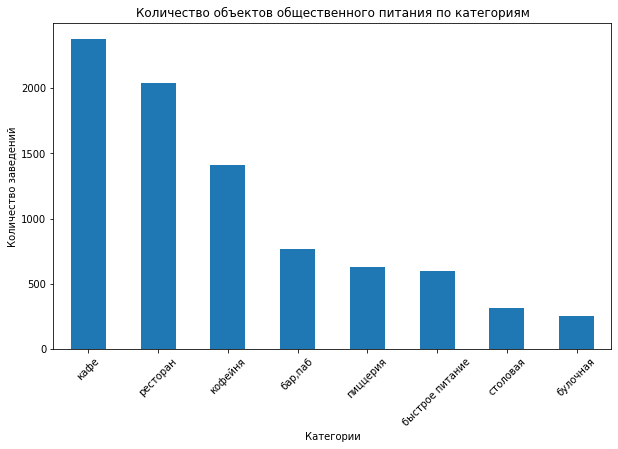

In [24]:
# Создаём столбчатую диаграмму по категориям заведений
plt.figure(figsize=(10, 6))
preprocessed_df['category'].value_counts().plot(kind='bar', legend=False, rot=45)
plt.title('Количество объектов общественного питания по категориям')
plt.xlabel('Категории')
plt.ylabel('Количество заведений')
plt.show()

Исходя из полученных данных большую часть заведений в Москве составляют кафе, рестораны, кофейни, а меньшую - столовые и булочные.

---

**Задача 2: Исследование распределения количества заведений по административным районам Москвы, а также распределения заведений каждой категории в Центральном административном округе Москвы.**

In [25]:
# Выводим количество заведений по административным районам Москвы
display('Количество объектов общественного питания по категориям:')
preprocessed_df['district'].value_counts()

'Количество объектов общественного питания по категориям:'

Центральный административный округ         2242
Северный административный округ             900
Южный административный округ                892
Северо-Восточный административный округ     891
Западный административный округ             851
Восточный административный округ            798
Юго-Восточный административный округ        714
Юго-Западный административный округ         709
Северо-Западный административный округ      409
Name: district, dtype: int64

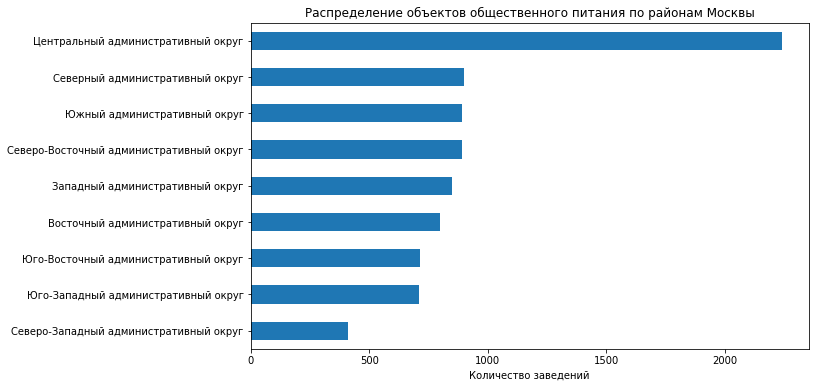

In [26]:
# Создаём столбчатую диаграмму по районам Москвы
plt.figure(figsize=(10, 6))
preprocessed_df['district'].value_counts().sort_values(ascending=True).plot(kind='barh', legend=False, rot=0)
plt.title('Распределение объектов общественного питания по районам Москвы')
plt.xlabel('Количество заведений')
plt.show()

Большая часть заведений расположена в Центральном административном округе. В Северо-Западном административном округе объектов общественного питания меньше всего.

In [27]:
# Фильтруем данные по Центральному административному округу
central_district_df = preprocessed_df[preprocessed_df['district'] == 'Центральный административный округ']

In [28]:
# Выводим количество заведений по Центральному административному округу
display('Количество объектов общественного питания в Центральном административном округе:')
central_district_df['category'].value_counts()

'Количество объектов общественного питания в Центральном административном округе:'

ресторан           670
кафе               464
кофейня            428
бар,паб            364
пиццерия           113
быстрое питание     87
столовая            66
булочная            50
Name: category, dtype: int64

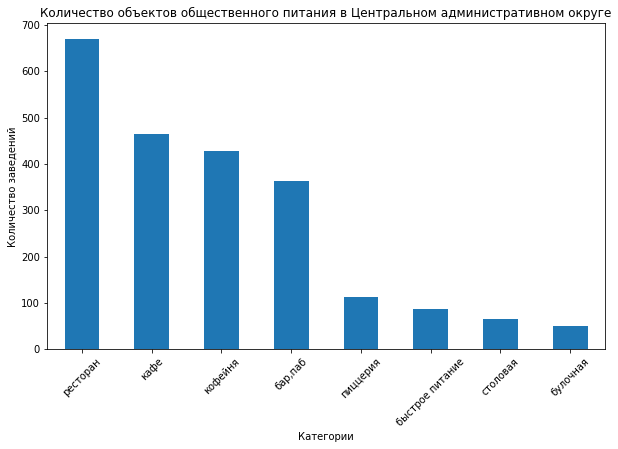

In [29]:
# Создаём столбчатую диаграмму по Центральному административному округу
plt.figure(figsize=(10, 6))
central_district_df['category'].value_counts().plot(kind='bar', legend=False, rot=45)
plt.title('Количество объектов общественного питания в Центральном административном округе')
plt.xlabel('Категории')
plt.ylabel('Количество заведений')
plt.show()

Распростронение категорий заведений в Центральном административном округе в целом такое же, как и по всем районам Москвы. Больше всего в Центральном административном округе заведений категорий ресторан, кафе, кофейня, бар (паб). 

---

**Задача 3: Анализ сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения.**

In [30]:
# Выводим соотношение сетевых и несетевых заведений (0 — заведение не является сетевым, 1 — заведение является сетевым)
display('Соотношение сетевых и несетевых заведений:')
preprocessed_df['chain'].value_counts(normalize=True)

'Соотношение сетевых и несетевых заведений:'

0    0.618725
1    0.381275
Name: chain, dtype: float64

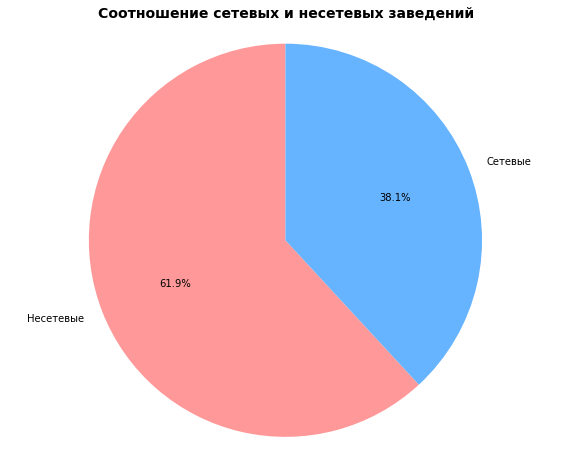

In [31]:
# Создаём круговую диаграмму для соотношения значений
plt.figure(figsize=(10, 8))
chain_data = preprocessed_df['chain'].value_counts(normalize=True)
labels = ['Несетевые', 'Сетевые']
colors = ['#ff9999', '#66b3ff']
plt.pie(chain_data, labels=labels, autopct='%1.1f%%', colors=colors, 
         startangle=90)
plt.title('Соотношение сетевых и несетевых заведений', fontsize=14, fontweight='bold')
plt.axis('equal')  
plt.show()

Почти 40% заведений в Москве являются сетевыми

In [32]:
# Выводим соотношение сетевых и несетевых заведений в разрезе категорий
display('Соотношение сетевых и несетевых заведений в разрезе категорий:')
gp = preprocessed_df.groupby('category')['chain'].value_counts(normalize=True)
gp

'Соотношение сетевых и несетевых заведений в разрезе категорий:'

category         chain
бар,паб          0        0.779085
                 1        0.220915
булочная         1        0.613281
                 0        0.386719
быстрое питание  0        0.615257
                 1        0.384743
кафе             0        0.672414
                 1        0.327586
кофейня          1        0.509554
                 0        0.490446
пиццерия         1        0.521327
                 0        0.478673
ресторан         0        0.642682
                 1        0.357318
столовая         0        0.720635
                 1        0.279365
Name: chain, dtype: float64

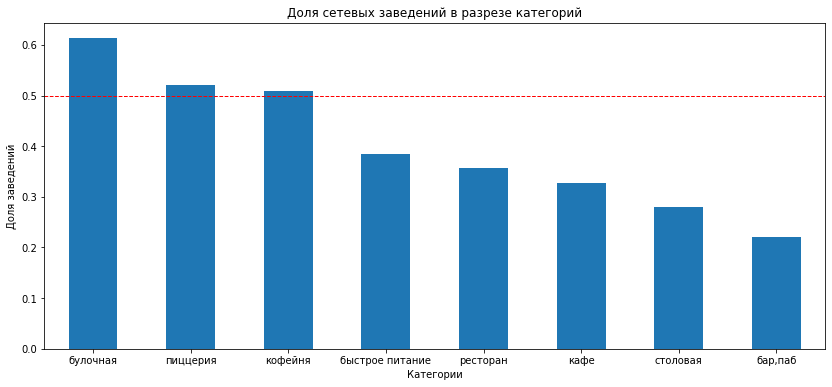

In [33]:
# Создаём столбчатую диаграмму для соотношения значений
plt.figure(figsize=(30, 18))
gp.unstack(fill_value=0)[1].sort_values(ascending=False).plot(kind='bar',
        title=f'Доля сетевых заведений в разрезе категорий',
        rot=0, 
        legend=False,
        ylabel='Доля заведений',
        xlabel='Категории',
        figsize=(14, 6))
plt.axhline(0.5, color='red',
                linestyle='--', linewidth=1)
plt.show()

Преобладающее значение сетевые заведения имеют в категориях булочная,пиццерия, кофейня.

---

**Задача 4: Исследование количества посадочных мест в заведениях.**

In [34]:
# Выводим статистику по полю seats
preprocessed_df['seats'].describe()

count    4795.000000
mean      108.421689
std       122.833396
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64

Судя по описательной статистике типичным для объектов общественного питания является 75 посадочных мест, а около половины заведений имеют от 40 до 140 мест. Стандартное отклонение 122.83 может свидетельствовать о высоком разбросе данных, что частично подтверждается разницой между минимальным и максимальным значениями.

Преобладание среднего значения над медианным показывает, что распределение значений смещено вправо.

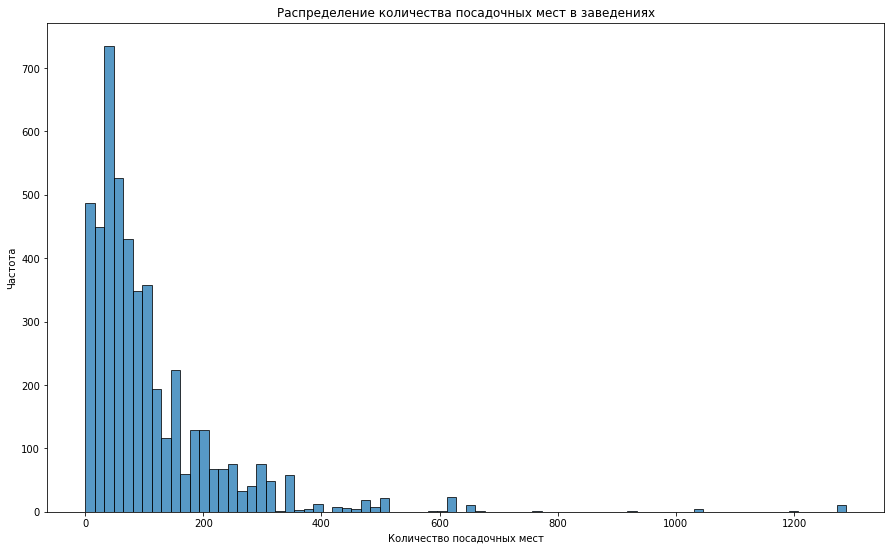

In [35]:
# Создаём график распределения значений в столбце seats
plt.figure(figsize=(15, 9))
preprocessed_df['seats'].plot(
                kind='hist', 
                bins=80, 
                alpha=0.75,
                edgecolor='black',
                rot=0,
)
plt.title('Распределение количества посадочных мест в заведениях')
plt.xlabel('Количество посадочных мест')
plt.ylabel('Частота')
plt.show()

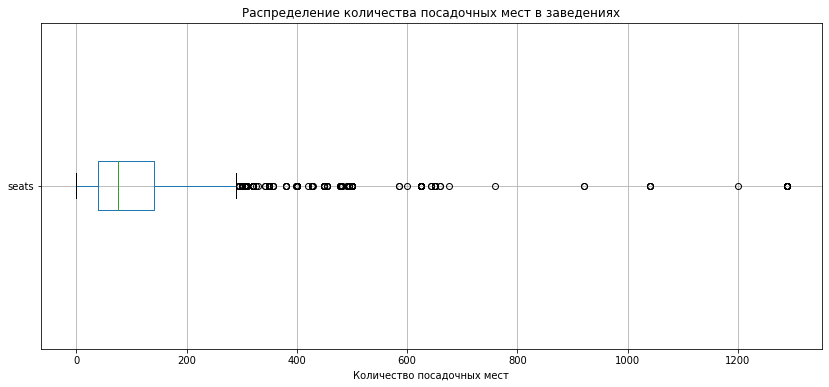

In [36]:
# Создаём диаграмму размаха для поля seats
plt.figure(figsize=(14, 6))
preprocessed_df.boxplot(column='seats', vert=False)
plt.title('Распределение количества посадочных мест в заведениях')
plt.xlabel('Количество посадочных мест')
plt.show()

Распределение данных характерезуется правосторонней ассиметрией с наличием длинного хвоста в правой части гистограммы, содержащий в себя большое количество выбросов и аномальные значения. Наличие таких выбросов, как, например, заведение с 1288 посадочных мест, может свидетельствовать либо об ощибках и неправельном заполнении данных, либо о наличии крупных заведений с большим количеством мест. Также ошибкой или результатом неправильно заполненных данных могут являються заведения с отсутствующими посадочными местами.

In [37]:
# Выделяем медианные значения посадочных мест для каждой категории
typical_seats_by_category = preprocessed_df.groupby('category')['seats'].median().round()
display('Наиболее типичное количество мест по категориям (медиана):')
typical_seats_by_category

'Наиболее типичное количество мест по категориям (медиана):'

category
бар,паб            82.0
булочная           50.0
быстрое питание    65.0
кафе               60.0
кофейня            80.0
пиццерия           55.0
ресторан           86.0
столовая           76.0
Name: seats, dtype: float64

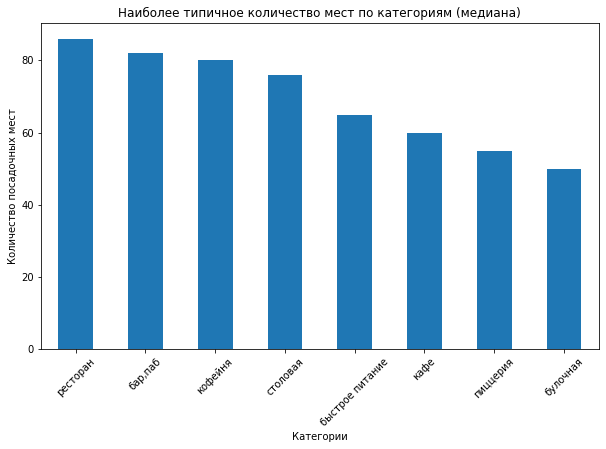

In [38]:
# Выводим диаграмму для сравнения типичного количества мест для каждой категории заведений 
plt.figure(figsize=(10, 6))
typical_seats_by_category.sort_values(ascending=False).plot(kind='bar', legend=False, rot=45)
plt.title('Наиболее типичное количество мест по категориям (медиана)')
plt.xlabel('Категории')
plt.ylabel('Количество посадочных мест')
plt.show()

Исходя из столбчатой диаграммы для ресторанов и баров характерны более просторные помещения (более 80 посадочных мест), а более камерные (50 - 60 мест) - для булочных, пиццерий и кафе.

---

**Задача 5: Исследование рейтинга заведений.**

In [39]:
# Выводим средний рейтинг по всем заведениям и по отдельным категориям
rating_by_category = preprocessed_df.groupby('category')['rating'].mean().round(2)
avg_rating = round(preprocessed_df['rating'].mean(), 2)
display('Средний рейтинг по категориям:', rating_by_category, 'Средний рейтинг по заведениям:', avg_rating)

'Средний рейтинг по категориям:'

category
бар,паб            4.39
булочная           4.27
быстрое питание    4.05
кафе               4.12
кофейня            4.28
пиццерия           4.30
ресторан           4.29
столовая           4.21
Name: rating, dtype: float64

'Средний рейтинг по заведениям:'

4.23

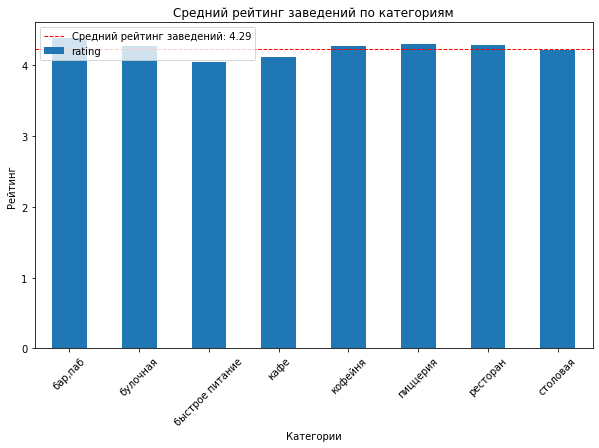

In [40]:
# Выводим диаграмму для сравнения среднего рейтинга по категориям
plt.figure(figsize=(10, 6))
rating_by_category.plot(kind='bar', legend=False, rot=45)
plt.title('Средний рейтинг заведений по категориям')
plt.xlabel('Категории')
plt.ylabel('Рейтинг')
# Наносим на график линию со средним значением рейтинга
plt.axhline(avg_rating, color='red',
                linestyle='--', linewidth=1,
                label='Средний рейтинг заведений: 4.29')
plt.legend()
plt.show()

Средние оценки заведений по категориям практически не отличаются друг от друга и от средней оценки по всем заведениям. Таким образом, можно сделать вывод, что рейтинг заведения не зависит от его категории.

---

**Задача 6: Анализ корреляции рейтингов заведений.**



In [41]:
# Формируем матрицу корреляции по полям, котрые возможно оказывают влияние на изменение рейтинга 
columns_for_matrix = ['rating', 'category', 'district', 'chain', 'seats', 'price', 'is_24_7']
rating_phik_matrix = preprocessed_df[columns_for_matrix].phik_matrix()
rating_phik_matrix.loc[rating_phik_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)

interval columns not set, guessing: ['rating', 'chain', 'seats']


,rating
price,0.220295
district,0.200691
category,0.190003
is_24_7,0.150173
chain,0.108092
seats,0.000000


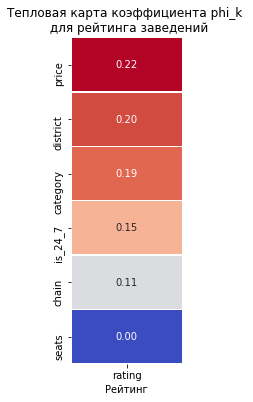

In [42]:
# Строим тепловую карту корреляции рейтинга заведений
plt.figure(figsize=(2, 6))
data_heatmap = rating_phik_matrix.loc[rating_phik_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)
sns.heatmap(data_heatmap,
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm', 
            linewidths=0.5,
            cbar=False
           )
plt.title('Тепловая карта коэффициента phi_k \n для рейтинга заведений')
plt.xlabel('Рейтинг')
plt.show()

Результаты кореляционного анализа рейтинга заведений показывает наличие слабой положительной корреляции с категорией цен, районом, категорией заведения, режимом работы 24/7, и статусом сетевого заведения. Связь между рейтингом и количеством посадочных мест отсутствует.
Самая сильная связь наблюдается с категорией цен.

In [43]:
# Изучаем взаимосвязь рейтинга с категориями цен
rating_by_price = preprocessed_df.groupby('price')['rating'].mean().sort_values(ascending=False).round(2)
rating_by_price

price
высокие          4.44
выше среднего    4.39
средние          4.30
низкие           4.17
Name: rating, dtype: float64

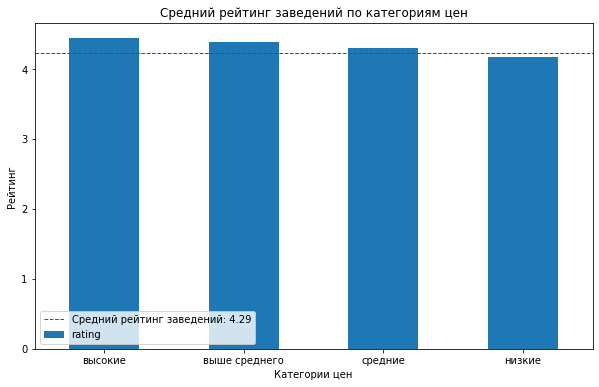

In [44]:
# Выводим диаграмму для сравнения среднего рейтинга по категориям цен
plt.figure(figsize=(10, 6))
rating_by_price.plot(kind='bar', legend=False, rot=0)
plt.title('Средний рейтинг заведений по категориям цен')
plt.xlabel('Категории цен')
plt.ylabel('Рейтинг')
# Наносим на график линию со средним значением рейтинга
plt.axhline(avg_rating, color='red',
                linestyle='--', linewidth=1,
                label='Средний рейтинг заведений: 4.29')
plt.legend()
plt.show()

При увеличении ценовой категории увеличивается рейтинг заведения. Это может свидетелствовать о том, что заведения высокого класса с высокими ценами имеют более высокий рейтинг, чем простые заведения с низкими ценами.

---

**Задача 7: Изучение популярных сетей в Москве.**

In [45]:
# Выводим Топ-15 популярных сетевых заведений
top_gp = preprocessed_df.groupby('name').agg(count = ('name', 'count'), avg = ('rating', 'mean'), category=('category', 'first'))
top_15 = top_gp.sort_values(by='count', ascending=False).head(15).round(2)
top_15 = top_15.reset_index()
top_15

,name,count,avg,category
0,Кафе,189,3.88,кафе
1,Шоколадница,120,4.18,кофейня
2,Домино'с Пицца,76,4.17,пиццерия
3,Додо Пицца,74,4.29,пиццерия
4,One Price Coffee,71,4.06,кофейня
5,Яндекс Лавка,69,3.87,ресторан
6,Cofix,65,4.08,кофейня
7,Prime,50,4.12,ресторан
8,Хинкальная,44,4.32,быстрое питание
9,Шаурма,43,3.91,быстрое питание


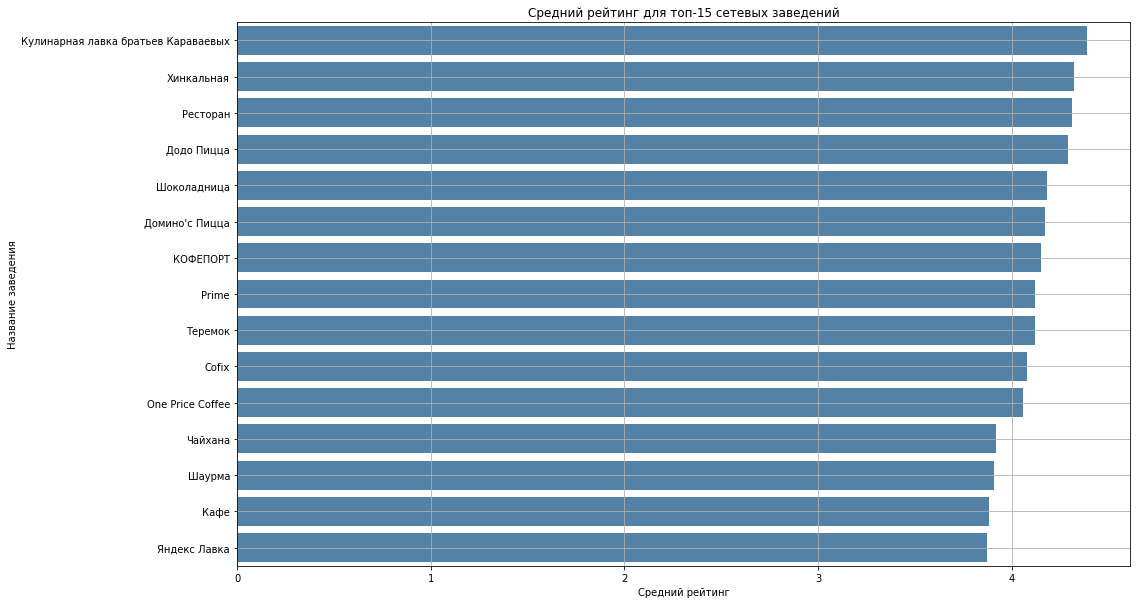

In [46]:
# Выводим диаграмму рейнтинга популярных сетевых заведений
top_15_sorted = top_15.sort_values('avg', ascending=False)
plt.figure(figsize=(16, 10))
sns.barplot(data=top_15_sorted, x='avg', y='name', color='steelblue')
plt.title('Средний рейтинг для топ-15 сетевых заведений')
plt.xlabel('Средний рейтинг')
plt.ylabel('Название заведения')
plt.grid()
plt.show()

In [47]:
# Определяем категории популярных сетевых заведений
display ('Категории популярных сетевых заведений: ', top_15['category'].value_counts())

'Категории популярных сетевых заведений: '

кофейня            4
ресторан           4
кафе               3
быстрое питание    2
пиццерия           2
Name: category, dtype: int64

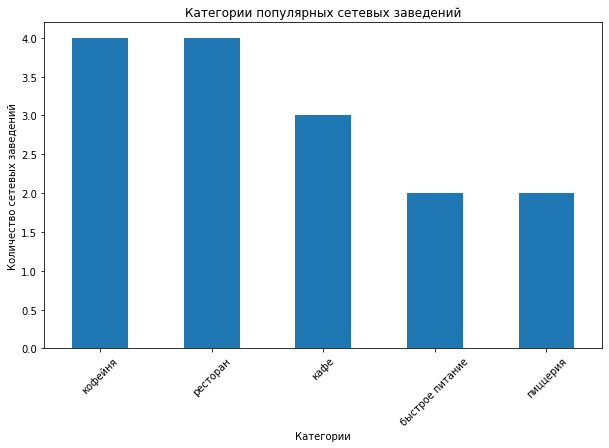

In [48]:
# Создаём диаграмму для сравнения категорий популярных сетевых заведений
plt.figure(figsize=(10, 6))
top_15['category'].value_counts().plot(kind='bar', legend=False, rot=45)
plt.title('Категории популярных сетевых заведений')
plt.xlabel('Категории')
plt.ylabel('Количество сетевых заведений')
plt.show()

К самым рейтинговым заведениям можно отнести "Кулинарная лавка братьев Караваевых", "Хинкальная", "Ресторан", "Додо Пицца", "Шоколадница". Рестораны и кофейни являются наиболее распространёнными категориями, среди топ-15 популярных франшиз объектов общественного питания.

---

**Задача 8: Анализ среднего чека заведений.**

In [49]:
# Выводим средний чек по районам
middle_avg_bill_by_district = preprocessed_df.groupby('district')['middle_avg_bill'].mean().round(2)
middle_avg_bill_by_district = middle_avg_bill_by_district.reset_index()
sorted_middle_avg_bill_by_district = middle_avg_bill_by_district.sort_values('middle_avg_bill', ascending=False) 
middle_avg_bill_by_all = round(preprocessed_df['middle_avg_bill'].mean(), 2)
display ('Средний чек по районам:', sorted_middle_avg_bill_by_district, 'Средний чек по всем заведениям:', middle_avg_bill_by_all)

'Средний чек по районам:'

,district,middle_avg_bill
5,Центральный административный округ,1191.06
1,Западный административный округ,1053.23
2,Северный административный округ,927.96
8,Южный административный округ,834.40
4,Северо-Западный административный округ,822.22
0,Восточный административный округ,820.63
7,Юго-Западный административный округ,792.56
3,Северо-Восточный административный округ,716.61
6,Юго-Восточный административный округ,654.10


'Средний чек по всем заведениям:'

958.05

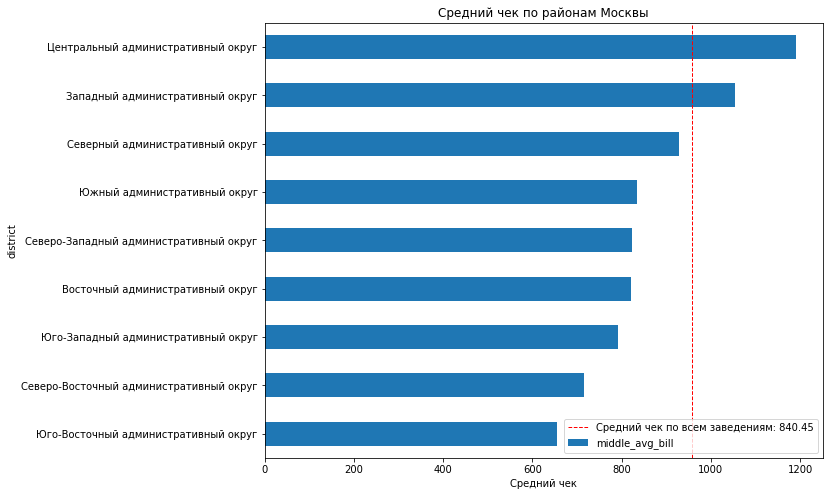

In [50]:
# Создаём диаграмму по районам Москвы
plt.figure(figsize=(10, 8))
preprocessed_df.groupby('district')['middle_avg_bill'].mean().sort_values().plot(kind='barh', legend=False, rot=0)
plt.title('Средний чек по районам Москвы')
plt.xlabel('Средний чек')
# Наносим на график линию с значением среднего чека
plt.axvline(middle_avg_bill_by_all, color='red',
                linestyle='--', linewidth=1,
                label='Средний чек по всем заведениям: 840.45')
plt.legend(loc='lower right')
plt.show()

Исходя из анализа Центральный административный округ является районом с самым большим средним чеком (1191.06). При этом, в Центральном и Заподном районе Москвы средний чек выше, чем средний чек по всем заведениям. Районами с самым низким средним чеком являются Юго-Западный, Северо-Восточный, Юго-Восточный округ.

---

## Промежуточный вывод

Исследовательский анализ данных показал следующее:

- Большую часть заведений в Москве составляют кафе, рестораны, кофейни, а меньшую - столовые и булочные. Основное количество заведений расположено в Центральном административном округе. В Северо-Западном административном округе объектов общественного питания меньше всего.
- Распростронение категорий заведений в Центральном административном округе в целом такое же, как и по всем районам Москвы. Больше всего в Центральном административном округе заведений категорий ресторан, кафе, кофейня, бар (паб).
- Почти 40% заведений в Москве являются сетевыми. Преобладающее значение сетевые заведения имеют в категориях булочная, пиццерия, кофейня. Популярные сетевые заведения в основном расположены в категориях рестораны и кофейни. К самым рейтинговым заведениям можно отнести "Кулинарная лавка братьев Караваевых", "Хинкальная", "Ресторан", "Додо Пицца", "Шоколадница".
- Типичным для объектов общественного питания является 75 посадочных мест, а около половины заведений имеют от 40 до 140 мест. Для баров и ресторанов характерны более просторные помещения (более 80 посадочных мест), а более камерные (50 - 60 мест) - для булочных, пиццерий и кафе.
- Рейтинга заведений показывает наличие слабой положительной корреляции с категорией цен, районом, категорией заведения, режимом работы 24/7 и статусом сетевого заведения. Связь между рейтингом и количеством посадочных мест отсутствует. При увеличении ценовой категории увеличивается рейтинг заведения. Это может свидетелствовать о том, что заведения высокого класса с высокими ценами имеют более высокий рейтинг, чем простые заведения с низкими ценами.
- Центральный административный округ является районом с самым большим средним чеком (1191.06). При этом, в Центральном и Западном районе Москвы средний чек выше, чем средний чек по всем заведениям. Районами с самым низким средним чеком являются Юго-Западный, Северо-Восточный, Юго-Восточный округ.

## Итоговый вывод и рекомендации

Исследование проводилось в целях анализа рынка заведений общественного питания Москвы. В ходе исследования было проанализировано 8406 объектов общественного питания Москвы. Данные включали в себя информацию о заведениях города, а также о среднем чеке в заведениях. Были проанализированы такие характеристики, как расположение объектов питания, категории заведений, их рейтинг, количество посадочных мест и средний чек. Отдельное внимание было уделено сетевым заведениям общественного питания.

**Структура рынка общественного питания в Москве**

На основе исследовательского анализа выявлены следующие особенности рынка общественного питания в Москве: 

- Основу рынка составляют кафе, рестораны, кофейни.
- Заведения в основном концентрируются в Центральном административном округе.
- Около 40% рынка занято сетевыми заведениями.
- Для Центрального и Западного района Москвы характерен более высокий средний чек.
- Более половины заведений имеют от 40 до 140 мест, наиболее типичным является 75 посадочных мест.

**Рекомендации для открытия заведения**

В качестве категории заведения стоит обратить внимание на следующие варианты:

1) Ресторан: большая популярность, перспективы в сегменте высокого класса, возможность поработать с популярными франшизами ("Ресторан", "Теремок", "Prime"). Рекомендуемое количество посадочных мест: 86

2) Кофейня: высокая популярность и возможность открытия популярной франшизы ("Шоколадница", "One Price Coffee", "Cofix"). Рекомендуемое количество посадочных мест: 80

3) Кафе: большая популярность и возможность открытия популярной франшизы ("Кафе", "Кулинарная лавка братьев Караваевых", "Цайхана"). Рекомендуемое количество посадочных мест: 60

4) Булочная: низкая конкуренция и сетевой эффект заведения. Рекомендуемое количество посадочных мест: 50

Также стоит рассмотреть вопрос создания заведения премиум-сегмента, т.к. заведения высокого класса с высокими ценами имеют более высокий рейтинг, чем простые заведения с низкими ценами. Для заведений высокого класса стоит рассмотреть Центральный или Западный район Москвы, так как для этих округов характерен высокий средний чек. Особое внимание следует обратить на Западный административный округ, потому что количество заведений в этом районе намного меньше, чем в Центральном, что свидетельствует о более низкой конкуренции. Для более простых заведений можно рассмотреть Юго-Западный, Северо-Восточный, Юго-Восточный округ.